Шаг 3: модели

In [122]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols


df = pd.read_csv("drom_cleaned.csv")
df.columns = df.columns.str.replace(" ", "_").str.replace("-", "_")

df = df.rename(columns={
    'Стоимость': 'Price',
    'Пробег': 'Mileage',
    'Объём_двигателя': 'EngineVolume',
    'Возраст_мотоцикла': 'Age',
    'Коробка_(код)': 'Gearbox',
    'Тактность_(код)': 'Stroke',
    'Подача_топлива_(код)': 'FuelSys'
})

df['log_Price'] = np.log(df['Price'])
df['log_Mileage'] = np.log1p(df['Mileage'])
df['log_EngineVolume'] = np.log1p(df['EngineVolume'])
df['log_Age'] = np.log1p(df['Age'])

brand_cols = [col for col in df.columns if col.startswith("Бренд_")]
region_cols = [col for col in df.columns if col.startswith("Город_")]

X1 = "Mileage + EngineVolume + Age"
X2 = X1 + " + Gearbox + Stroke + FuelSys"
X3 = X2 + " + " + " + ".join(brand_cols + region_cols)

X1_logX = "log_Mileage + log_EngineVolume + log_Age"
X2_logX = X1_logX + " + Gearbox + Stroke + FuelSys"
X3_logX = X2_logX + " + " + " + ".join(brand_cols + region_cols)

formulas = {
    "LINEAR_1": f"Price ~ 0 + {X1}",
    "LINEAR_2": f"Price ~ 0 + {X2}",
    "LINEAR_3": f"Price ~ 0 + {X3}",
    "SEMI_4": f"log_Price ~ 0 + {X1}",
    "SEMI_5": f"log_Price ~ 0 + {X2}",
    "SEMI_6": f"log_Price ~ 0 + {X3}",
    "LOG_7": f"log_Price ~ 0 + {X1_logX}",
    "LOG_8": f"log_Price ~ 0 + {X2_logX}",
    "LOG_9": f"log_Price ~ 0 + {X3_logX}",
}

results = []
equations = {}

for name, formula in formulas.items():
    model = ols(formula, data=df).fit()
    results.append({
        "Model": name,
        "R²": model.rsquared,
        "Adj. R²": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic
    })

    if name.startswith("SEMI"):
        lhs = "log(Y)"
    elif name.startswith("LOG"):
        lhs = "log(Y)"
    else:
        lhs = "Y"

    coeffs = model.params
    rhs = " + ".join([f"{v:.3f}·{k}" for k, v in coeffs.items()])
    equations[name] = f"{lhs} = {rhs}"

metrics_df = pd.DataFrame(results).round(3)

print("Сравнение моделей:")
print(metrics_df.to_string(index=False))

print("Уравнения моделей:")
for model_name in formulas:
    print(equations[model_name])


Сравнение моделей:
   Model    R²  Adj. R²        AIC        BIC
LINEAR_1 0.735    0.735 237573.043 237594.118
LINEAR_2 0.758    0.758 236808.672 236850.821
LINEAR_3 0.618    0.617 235999.914 236168.511
  SEMI_4 0.715    0.714  55416.550  55437.624
  SEMI_5 0.964    0.964  38280.723  38322.872
  SEMI_6 0.776    0.775  10193.336  10361.932
   LOG_7 0.994    0.994  23518.736  23539.811
   LOG_8 0.994    0.994  22642.915  22685.064
   LOG_9 0.812    0.812   8712.694   8881.291
Уравнения моделей:
Y = -3.672·Mileage + 1137.569·EngineVolume + -9325.318·Age
Y = -4.167·Mileage + 897.266·EngineVolume + -7387.604·Age + 129951.358·Gearbox + 20137.261·Stroke + 272758.394·FuelSys
Y = -3.581·Mileage + 771.368·EngineVolume + -11926.307·Age + 106719.932·Gearbox + -257642.743·Stroke + 211969.430·FuelSys + -10663.543·Бренд_Benelli + 132296.826·Бренд_CFMoto + 297283.310·Бренд_Ducati + 603515.519·Бренд_Harley_Davidson + 192564.210·Бренд_Honda + 156329.469·Бренд_Indian + 120511.249·Бренд_Kawasaki + -639.19

In [123]:
from scipy import stats
import statsmodels.api as sm

y = df['Price'].values
X = df[['Mileage', 'EngineVolume', 'Age', 'Gearbox', 'Stroke', 'FuelSys']]
X = sm.add_constant(X)

_, lambda_opt = stats.boxcox(y)

print(f"Box-Cox λ: {lambda_opt:.6f}")


Box-Cox λ: -0.005447


In [124]:
import statsmodels.stats.diagnostic as smd

formula_linear2 = formulas["LINEAR_2"]
formula_semi5 = formulas["SEMI_5"]
formula_log8 = formulas["LOG_8"]

model_linear2 = ols(formula_linear2, data=df).fit()
model_semi5 = ols(formula_semi5, data=df).fit()
model_log8 = ols(formula_log8, data=df).fit()

reset_linear2 = smd.linear_reset(model_linear2, power=2, use_f=True)
reset_semi5 = smd.linear_reset(model_semi5, power=2, use_f=True)
reset_log8 = smd.linear_reset(model_log8, power=2, use_f=True)

print("\nRESET-тест (Ramsey):")
print(f"LINEAR_2 — F = {reset_linear2.fvalue:.4f}, p = {reset_linear2.pvalue:.4f}")
print(f"SEMI_5   — F = {reset_semi5.fvalue:.4f}, p = {reset_semi5.pvalue:.4f}")
print(f"LOG_8    — F = {reset_log8.fvalue:.4f}, p = {reset_log8.pvalue:.4f}")



RESET-тест (Ramsey):
LINEAR_2 — F = 1409.1451, p = 0.0000
SEMI_5   — F = 11094.0325, p = 0.0000
LOG_8    — F = 22548.2693, p = 0.0000


In [125]:
import statsmodels.stats.diagnostic as smd

formula_linear3 = formulas["LINEAR_3"]
formula_semi6 = formulas["SEMI_6"]
formula_log9 = formulas["LOG_9"]

model_linear3 = ols(formula_linear3, data=df).fit()
model_semi6 = ols(formula_semi6, data=df).fit()
model_log9 = ols(formula_log9, data=df).fit()

reset_linear3 = smd.linear_reset(model_linear3, power=2, use_f=True)
reset_semi6 = smd.linear_reset(model_semi6, power=2, use_f=True)
reset_log9 = smd.linear_reset(model_log9, power=2, use_f=True)

print("\nRESET-тест (LINEAR_3, SEMI_6, LOG_9):")
print(f"LINEAR_3 — F = {reset_linear3.fvalue:.4f}, p = {reset_linear3.pvalue:.4f}")
print(f"SEMI_6   — F = {reset_semi6.fvalue:.4f}, p = {reset_semi6.pvalue:.4f}")
print(f"LOG_9    — F = {reset_log9.fvalue:.4f}, p = {reset_log9.pvalue:.4f}")



RESET-тест (LINEAR_3, SEMI_6, LOG_9):
LINEAR_3 — F = 2349.8940, p = 0.0000
SEMI_6   — F = 790.3561, p = 0.0000
LOG_9    — F = 57.0306, p = 0.0000


In [126]:
import statsmodels.stats.diagnostic as smd
from statsmodels.formula.api import ols

formula_linear1 = formulas["LINEAR_1"]
formula_semi4 = formulas["SEMI_4"]
formula_log7 = formulas["LOG_7"]

model_linear1 = ols(formula_linear1, data=df).fit()
model_semi4 = ols(formula_semi4, data=df).fit()
model_log7 = ols(formula_log7, data=df).fit()

reset_linear1 = smd.linear_reset(model_linear1, power=2, use_f=True)
reset_semi4 = smd.linear_reset(model_semi4, power=2, use_f=True)
reset_log7 = smd.linear_reset(model_log7, power=2, use_f=True)

print("\nRESET-тест (LINEAR_1, SEMI_4, LOG_7):")
print(f"LINEAR_1 — F = {reset_linear1.fvalue:.4f}, p = {reset_linear1.pvalue:.4f}")
print(f"SEMI_4   — F = {reset_semi4.fvalue:.4f}, p = {reset_semi4.pvalue:.4f}")
print(f"LOG_7    — F = {reset_log7.fvalue:.4f}, p = {reset_log7.pvalue:.4f}")



RESET-тест (LINEAR_1, SEMI_4, LOG_7):
LINEAR_1 — F = 186.5112, p = 0.0000
SEMI_4   — F = 15679.3479, p = 0.0000
LOG_7    — F = 16283.7943, p = 0.0000


In [127]:
from statsmodels.formula.api import ols

formula_log8 = "log_Price ~ 0 + log_Mileage + log_EngineVolume + log_Age + Gearbox + Stroke + FuelSys"

model_log8 = ols(formula_log8, data=df).fit()

coeffs = model_log8.params
equation = "log(Y) = " + " + ".join([f"{v:.4f}·{k}" for k, v in coeffs.items()])

print(equation)

log(Y) = -0.0459·log_Mileage + 2.0366·log_EngineVolume + -0.1528·log_Age + 0.3578·Gearbox + 1.1460·Stroke + -0.2958·FuelSys


In [128]:
print(model_log8.summary())

residuals = model_log8.resid
fitted = model_log8.fittedvalues


                                 OLS Regression Results                                
Dep. Variable:              log_Price   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.994
Method:                 Least Squares   F-statistic:                          2.493e+05
Date:                Thu, 08 May 2025   Prob (F-statistic):                        0.00
Time:                        20:01:44   Log-Likelihood:                         -11315.
No. Observations:                8307   AIC:                                  2.264e+04
Df Residuals:                    8301   BIC:                                  2.269e+04
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------


Jarque-Bera: stat = 2504.17, p = 0.0000
Shapiro-Wilk: stat = 0.9622, p = 0.0000


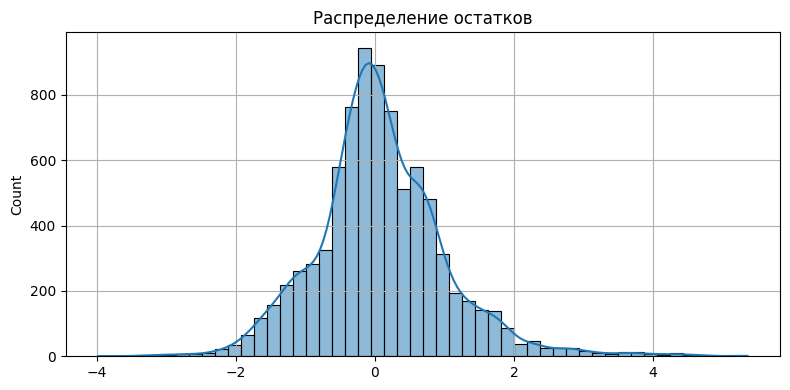

In [129]:
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

jb_stat, jb_pvalue, _, _ = jarque_bera(residuals)

shapiro_stat, shapiro_pvalue = shapiro(residuals.sample(n=5000, random_state=42))

print(f"\nJarque-Bera: stat = {jb_stat:.2f}, p = {jb_pvalue:.4f}")
print(f"Shapiro-Wilk: stat = {shapiro_stat:.4f}, p = {shapiro_pvalue:.4f}")

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Распределение остатков")
plt.grid(True)
plt.tight_layout()
plt.show()

In [130]:
import statsmodels.api as sm

X_with_const = sm.add_constant(model_log8.model.exog, has_constant='add')

bp_test = het_breuschpagan(residuals, X_with_const)
bp_stat, bp_pvalue, _, f_pvalue = bp_test

print(f"\nBreusch–Pagan: LM stat = {bp_stat:.2f}, p = {bp_pvalue:.4f}, F p = {f_pvalue:.4f}")



Breusch–Pagan: LM stat = 2009.67, p = 0.0000, F p = 0.0000


In [131]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = model_log8.model.exog
vif_df = pd.DataFrame({
    'Variable': model_log8.model.exog_names,
    'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})

print("\nVIF:")
print(vif_df.sort_values(by="VIF", ascending=False).round(2))



VIF:
           Variable    VIF
1  log_EngineVolume  31.40
4            Stroke  19.80
2           log_Age  11.76
0       log_Mileage  11.16
5           FuelSys   2.18
3           Gearbox   1.04


In [132]:
mean_log_mileage = df['log_Mileage'].mean()
mean_log_age = df['log_Age'].mean()

weight_age = mean_log_mileage / mean_log_age

df['log_UseIntensity_balanced'] = df['log_Mileage'] + weight_age * df['log_Age']

final_formula_nostroke = (
    "log_Price ~ 0 + log_UseIntensity_balanced + log_EngineVolume + Gearbox + FuelSys"
)

model_balanced = ols(final_formula_nostroke, data=df).fit()

from statsmodels.stats.outliers_influence import variance_inflation_factor
X_balanced = model_balanced.model.exog
vif_balanced_df = pd.DataFrame({
    'Variable': model_balanced.model.exog_names,
    'VIF': [variance_inflation_factor(X_balanced, i) for i in range(X_balanced.shape[1])]
})

print(f"Коэффициент для log_Age: {weight_age:.3f}")
print(vif_balanced_df.sort_values(by='VIF', ascending=False).round(2))


Коэффициент для log_Age: 3.577
                    Variable   VIF
1           log_EngineVolume  6.67
0  log_UseIntensity_balanced  6.01
3                    FuelSys  2.02
2                    Gearbox  1.04


In [133]:
print(model_balanced.summary())

summary_df = model_balanced.summary2().tables[1]
print("\nКоэффициенты модели:")
print(summary_df.round(4))


                                 OLS Regression Results                                
Dep. Variable:              log_Price   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.994
Method:                 Least Squares   F-statistic:                          3.481e+05
Date:                Thu, 08 May 2025   Prob (F-statistic):                        0.00
Time:                        20:01:45   Log-Likelihood:                         -11613.
No. Observations:                8307   AIC:                                  2.323e+04
Df Residuals:                    8303   BIC:                                  2.326e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [134]:
coeffs = model_balanced.params

rhs = " + ".join([f"{v:.4f}·{k}" for k, v in coeffs.items()])

equation = f"log(Y) = {rhs}"
print(equation)

log(Y) = -0.0521·log_UseIntensity_balanced + 2.2404·log_EngineVolume + 0.3945·Gearbox + -0.3831·FuelSys


In [135]:
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro
import statsmodels.api as sm

residuals = model_balanced.resid

X_with_const = sm.add_constant(model_balanced.model.exog, has_constant='add')

reset_result = linear_reset(model_balanced, power=2, use_f=True)

bp_stat, bp_pvalue, _, f_pvalue = het_breuschpagan(residuals, X_with_const)

jb_stat, jb_pvalue, _, _ = jarque_bera(residuals)

shapiro_stat, shapiro_pvalue = shapiro(residuals.sample(n=5000, random_state=42))

print("\nПроверка предпосылок модели:")
print(f"RESET-тест: F = {reset_result.fvalue:.2f}, p = {reset_result.pvalue:.4f}")
print(f"Breusch–Pagan: LM = {bp_stat:.2f}, p = {bp_pvalue:.4e}, F p = {f_pvalue:.4e}")
print(f"Jarque–Bera: stat = {jb_stat:.2f}, p = {jb_pvalue:.4e}")
print(f"Shapiro–Wilk: stat = {shapiro_stat:.4f}, p = {shapiro_pvalue:.4e}")




Проверка предпосылок модели:
RESET-тест: F = 24424.32, p = 0.0000
Breusch–Pagan: LM = 772.96, p = 5.5309e-166, F p = 3.3016e-174
Jarque–Bera: stat = 810.19, p = 1.1746e-176
Shapiro–Wilk: stat = 0.9846, p = 6.5257e-23


In [136]:
model_robust = model_balanced.get_robustcov_results(cov_type='HC1')

print("\nСводка модели с робастными стандартными ошибками:")
print(model_robust.summary())

coeffs_robust = model_robust.params
names = model_robust.model.exog_names
rhs_robust = " + ".join([f"{v:.4f}·{k}" for k, v in zip(names, coeffs_robust)])
equation_robust = f"log(Y) = {rhs_robust}"

print("\nУравнение модели (с робастными оценками):")
print(equation_robust)




Сводка модели с робастными стандартными ошибками:
                                 OLS Regression Results                                
Dep. Variable:              log_Price   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.994
Method:                 Least Squares   F-statistic:                          4.444e+05
Date:                Thu, 08 May 2025   Prob (F-statistic):                        0.00
Time:                        20:01:45   Log-Likelihood:                         -11613.
No. Observations:                8307   AIC:                                  2.323e+04
Df Residuals:                    8303   BIC:                                  2.326e+04
Df Model:                           4                                                  
Covariance Type:                  HC1                                                  
                                coef    std err          t      P>|t|

In [137]:
import pandas as pd

standard_errors = model_balanced.bse
robust_errors = model_robust.bse

comparison = pd.DataFrame({
    'Variable': model_balanced.model.exog_names,
    'Std. Err OLS': standard_errors,
    'Std. Err Robust': robust_errors,
    'Ratio (Robust / OLS)': robust_errors / standard_errors
}).round(4)

print("\nСравнение стандартных ошибок:")
print(comparison)



Сравнение стандартных ошибок:
                                            Variable  Std. Err OLS  \
log_UseIntensity_balanced  log_UseIntensity_balanced        0.0017   
log_EngineVolume                    log_EngineVolume        0.0046   
Gearbox                                      Gearbox        0.0616   
FuelSys                                      FuelSys        0.0234   

                           Std. Err Robust  Ratio (Robust / OLS)  
log_UseIntensity_balanced           0.0017                1.0166  
log_EngineVolume                    0.0036                0.7832  
Gearbox                             0.0619                1.0058  
FuelSys                             0.0251                1.0709  


In [138]:
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import shapiro
import statsmodels.api as sm

residuals = model_balanced.resid
X_with_const = sm.add_constant(model_balanced.model.exog, has_constant='add')

reset_result = linear_reset(model_balanced, power=2, use_f=True)

bp_stat, bp_pvalue, _, f_pvalue = het_breuschpagan(residuals, X_with_const)

jb_stat, jb_pvalue, _, _ = jarque_bera(residuals)

shapiro_stat, shapiro_pvalue = shapiro(residuals.sample(n=5000, random_state=42))

print("\nПроверка предпосылок для модели с робастными ошибками:")
print(f"RESET-тест: F = {reset_result.fvalue:.2f}, p = {reset_result.pvalue:.4f}")
print(f"Breusch–Pagan: LM = {bp_stat:.2f}, p = {bp_pvalue:.4e}, F p = {f_pvalue:.4e}")
print(f"Jarque–Bera: stat = {jb_stat:.2f}, p = {jb_pvalue:.4e}")
print(f"Shapiro–Wilk: stat = {shapiro_stat:.4f}, p = {shapiro_pvalue:.4e}")



Проверка предпосылок для модели с робастными ошибками:
RESET-тест: F = 24424.32, p = 0.0000
Breusch–Pagan: LM = 772.96, p = 5.5309e-166, F p = 3.3016e-174
Jarque–Bera: stat = 810.19, p = 1.1746e-176
Shapiro–Wilk: stat = 0.9846, p = 6.5257e-23


Предлагаем свой товар и оцениваем стоимость

In [139]:
test_features = {
    "Age": 5,                    # возраст в годах
    "Mileage": 11000,            # пробег в км
    "EngineVolume": 700,         # объём двигателя в куб.см
    "Gearbox": 1,                # 1 = механика
    "FuelSys": 1                 # 1 = инжектор
    # Stroke не используется
}

log_mileage = np.log1p(test_features["Mileage"])
log_age = np.log1p(test_features["Age"])
log_engine_volume = np.log1p(test_features["EngineVolume"])

log_use_intensity_balanced = log_mileage + weight_age * log_age

df_pred = pd.DataFrame([{
    "log_UseIntensity_balanced": log_use_intensity_balanced,
    "log_EngineVolume": log_engine_volume,
    "Gearbox": test_features["Gearbox"],
    "FuelSys": test_features["FuelSys"]
}])

log_price_pred = model_balanced.predict(df_pred)[0]
price_pred = np.exp(log_price_pred)

print(f"Прогнозируемая цена товара: {price_pred:,.0f} руб.")


Прогнозируемая цена товара: 1,059,053 руб.
